# HARGPT Raw Window Export

Cut ACC to the video-aligned subset once, build a window index, then generate a HARGPT-style prompt from 3 consecutive windows.

In [17]:
from pathlib import Path
import pandas as pd

from video_ltc import ensure_video_timecode_csv

PROJECT_ROOT = Path.cwd().resolve().parent
OUTPUT_DIR = Path.cwd() / "outputs"
VIDEO_DIR = Path.cwd() / "videos"
OUTPUT_DIR.mkdir(exist_ok=True)
VIDEO_DIR.mkdir(exist_ok=True)

PARTICIPANT_ID = "65"
VIDEO_NAME = "GL040226"
RECORD_DATE = pd.Timestamp("2025-07-17").date()
VIDEO_FILE = None
VIDEO_START_TIMECODE = None
VIDEO_FPS = None
FORCE_REGENERATE_VIDEO_METADATA = False

TARGET_FS = 50.0
WINDOW_SECONDS = 4.0
STRIDE_SECONDS = 2.0
WINDOW_SIZE = int(TARGET_FS * WINDOW_SECONDS)
STRIDE_SIZE = int(TARGET_FS * STRIDE_SECONDS)

WINDOW_INDEX_IN_VIDEO_SUBSET = 100
PROMPT_WINDOW_COUNT = 50

ACC_FILE = PROJECT_ROOT / "acc_files_cup" / PARTICIPANT_ID / "ACC_0.csv"
VIDEO_FILE, VIDEO_TIMECODE_FILE, VIDEO_METADATA_FILE = ensure_video_timecode_csv(
    video_name=VIDEO_NAME,
    video_file=VIDEO_FILE,
    videos_dir=VIDEO_DIR,
    fallback_timecode=VIDEO_START_TIMECODE,
    fallback_fps=VIDEO_FPS,
    regenerate=FORCE_REGENERATE_VIDEO_METADATA,
)
WINDOW_INDEX_CSV = OUTPUT_DIR / f"hargpt_window_index_{PARTICIPANT_ID}_{VIDEO_NAME}.csv"
ACC_VIDEO_CSV = OUTPUT_DIR / f"hargpt_acc_video_subset_{PARTICIPANT_ID}_{VIDEO_NAME}.csv"

def parse_time_column(series: pd.Series) -> pd.Series:
    return pd.to_datetime(series.astype(str).str.strip(), errors="coerce")

def load_cup_acc_csv(acc_file: Path) -> pd.DataFrame:
    df = pd.read_csv(acc_file)
    rename_map = {"X": "x", "Y": "y", "Z": "z"}
    df = df.rename(columns=rename_map)
    df = df[["time", "x", "y", "z"]].copy()
    df["time"] = parse_time_column(df["time"])
    df = df.dropna(subset=["time", "x", "y", "z"]).sort_values("time")
    df = df.drop_duplicates(subset=["time"]).reset_index(drop=True)
    return df

def resample_acc(df: pd.DataFrame, target_fs: float) -> pd.DataFrame:
    freq_ms = int(round(1000.0 / target_fs))
    rule = f"{freq_ms}ms"
    return (
        df.set_index("time")[["x", "y", "z"]]
        .resample(rule)
        .mean()
        .interpolate(method="time")
        .dropna()
        .reset_index()
    )

def load_video_range(video_timecode_file: Path, record_date):
    vid = pd.read_csv(video_timecode_file)
    vid["tc_hms"] = vid["tc_str"].astype(str).str.slice(0, 8)
    vid["video_datetime"] = pd.to_datetime(
        record_date.strftime("%Y-%m-%d") + " " + vid["tc_hms"],
        errors="coerce"
    )
    vid = vid.dropna(subset=["video_datetime"]).sort_values("video_datetime").reset_index(drop=True)
    return vid["video_datetime"].iloc[0], vid["video_datetime"].iloc[-1]

def split_windows(df: pd.DataFrame, window_size: int, stride_size: int) -> pd.DataFrame:
    rows = []
    if len(df) < window_size:
        return pd.DataFrame(rows)
    for start in range(0, len(df) - window_size + 1, stride_size):
        end = start + window_size
        window_df = df.iloc[start:end].copy().reset_index(drop=True)
        rows.append({
            "window_id": len(rows),
            "start_idx_in_video_subset": int(start),
            "end_idx_in_video_subset": int(end - 1),
            "start_time": window_df.loc[0, "time"],
            "end_time": window_df.loc[len(window_df) - 1, "time"],
        })
    return pd.DataFrame(rows)

raw_acc = load_cup_acc_csv(ACC_FILE)
acc_resampled = resample_acc(raw_acc, TARGET_FS)
video_start, video_end = load_video_range(VIDEO_TIMECODE_FILE, RECORD_DATE)
acc_video = acc_resampled[(acc_resampled["time"] >= video_start) & (acc_resampled["time"] <= video_end)].copy().reset_index(drop=True)
if len(acc_video) < WINDOW_SIZE:
    raise ValueError("Video subset is shorter than one analysis window.")

acc_video.to_csv(ACC_VIDEO_CSV, index=False)
window_index_df = split_windows(acc_video, WINDOW_SIZE, STRIDE_SIZE)
window_index_df.to_csv(WINDOW_INDEX_CSV, index=False)

print(f"Video file: {VIDEO_FILE}")
print(f"Video timecode CSV: {VIDEO_TIMECODE_FILE}")
print(f"Video metadata JSON: {VIDEO_METADATA_FILE}")
print(f"ACC video subset saved to: {ACC_VIDEO_CSV}")
print(f"Window index saved to: {WINDOW_INDEX_CSV}")
print(f"Video range: {video_start} -> {video_end}")
print(f"Video-subset windows: {len(window_index_df)}")
window_index_df.head()


Video file: G:\TUD_CESE\OneDrive - Delft University of Technology\Smart Cup\relativeWorks\hargpt_dir\cup_integration\videos\GL040226.lrv
Video timecode CSV: G:\TUD_CESE\OneDrive - Delft University of Technology\Smart Cup\relativeWorks\hargpt_dir\cup_integration\videos\video_timecode_1HzGL040226.csv
Video metadata JSON: G:\TUD_CESE\OneDrive - Delft University of Technology\Smart Cup\relativeWorks\hargpt_dir\cup_integration\videos\video_metadata_GL040226.json
ACC video subset saved to: G:\TUD_CESE\OneDrive - Delft University of Technology\Smart Cup\relativeWorks\hargpt_dir\cup_integration\outputs\hargpt_acc_video_subset_65_GL040226.csv
Window index saved to: G:\TUD_CESE\OneDrive - Delft University of Technology\Smart Cup\relativeWorks\hargpt_dir\cup_integration\outputs\hargpt_window_index_65_GL040226.csv
Video range: 2025-07-17 13:56:58 -> 2025-07-17 14:08:45
Video-subset windows: 352


,window_id,start_idx_in_video_subset,end_idx_in_video_subset,start_time,end_time
0,0,0,199,2025-07-17 13:56:58,2025-07-17 13:57:01.980
1,1,100,299,2025-07-17 13:57:00,2025-07-17 13:57:03.980
2,2,200,399,2025-07-17 13:57:02,2025-07-17 13:57:05.980
3,3,300,499,2025-07-17 13:57:04,2025-07-17 13:57:07.980
4,4,400,599,2025-07-17 13:57:06,2025-07-17 13:57:09.980


In [18]:
# Process weak labels
import json
import numpy as np

WEAK_LABEL_INPUT = PROJECT_ROOT / "weak_label" / f"{PARTICIPANT_ID}.json"
WEAK_LABEL_OUTPUT = PROJECT_ROOT / "weak_label" / f"weak_labels_{PARTICIPANT_ID}_{VIDEO_NAME}.csv"

label_to_state = {
    "Still": 0,
    "Gesture": 1,
    "Raise to lips": 2,
    "Drink": 3,
    "Return from lips": 4,
    "Nodding": 5,
}
label_priority = {
    "Still": 0,
    "Nodding": 1,
    "Gesture": 2,
    "Return from lips": 3,
    "Raise to lips": 4,
    "Drink": 5,
}

if not WEAK_LABEL_INPUT.exists():
    raise FileNotFoundError(f"Weak label file not found: {WEAK_LABEL_INPUT}")

weak_segments = json.loads(WEAK_LABEL_INPUT.read_text(encoding="utf-8"))
weak_df = pd.DataFrame(weak_segments)

required_cols = {"start", "end", "category"}
missing_cols = required_cols - set(weak_df.columns)
if missing_cols:
    raise ValueError(f"Weak label JSON missing required fields: {sorted(missing_cols)}")

weak_df = weak_df.copy()
weak_df["start"] = pd.to_numeric(weak_df["start"], errors="coerce")
weak_df["end"] = pd.to_numeric(weak_df["end"], errors="coerce")
weak_df["category"] = weak_df["category"].astype(str).str.strip()
weak_df = weak_df.dropna(subset=["start", "end", "category"]).sort_values(["start", "end"]).reset_index(drop=True)

invalid_segments = weak_df[weak_df["end"] < weak_df["start"]].copy()
if not invalid_segments.empty:
    raise ValueError("Weak label contains segments with end < start.")

unknown_categories = sorted(set(weak_df["category"]) - set(label_to_state))
if unknown_categories:
    raise ValueError(f"Unknown weak label categories: {unknown_categories}")

weak_df["abs_start"] = video_start + pd.to_timedelta(weak_df["start"], unit="s")
weak_df["abs_end"] = video_start + pd.to_timedelta(weak_df["end"], unit="s")
weak_df["clipped_start"] = weak_df["abs_start"].clip(lower=video_start, upper=video_end)
weak_df["clipped_end"] = weak_df["abs_end"].clip(lower=video_start, upper=video_end)
weak_df = weak_df[weak_df["clipped_end"] >= weak_df["clipped_start"]].reset_index(drop=True)

acc_weak = acc_video.copy()
acc_weak["time"] = pd.to_datetime(acc_weak["time"])
acc_weak["state"] = label_to_state["Still"]
acc_weak["weak_label"] = "Still"
priority_buffer = np.zeros(len(acc_weak), dtype=int)

for row in weak_df.itertuples(index=False):
    priority = label_priority[row.category]
    mask = (acc_weak["time"] >= row.clipped_start) & (acc_weak["time"] <= row.clipped_end)
    if not mask.any():
        continue
    mask_np = mask.to_numpy()
    update_mask = mask_np & (priority >= priority_buffer)
    if not update_mask.any():
        continue
    priority_buffer[update_mask] = priority
    acc_weak.loc[update_mask, "state"] = label_to_state[row.category]
    acc_weak.loc[update_mask, "weak_label"] = row.category

acc_weak["video_name"] = VIDEO_NAME
acc_weak = acc_weak[["time", "x", "y", "z", "state", "weak_label", "video_name"]]
acc_weak.to_csv(WEAK_LABEL_OUTPUT, index=False)

print(f"Weak label input: {WEAK_LABEL_INPUT}")
print(f"Weak label output: {WEAK_LABEL_OUTPUT}")
print(f"Video range: {video_start} -> {video_end}")
print(f"ACC rows labeled: {len(acc_weak)}")
print(acc_weak["weak_label"].value_counts().sort_index())
acc_weak.head()


Weak label input: G:\TUD_CESE\OneDrive - Delft University of Technology\Smart Cup\relativeWorks\hargpt_dir\weak_label\65.json
Weak label output: G:\TUD_CESE\OneDrive - Delft University of Technology\Smart Cup\relativeWorks\hargpt_dir\weak_label\weak_labels_65_GL040226.csv
Video range: 2025-07-17 13:56:58 -> 2025-07-17 14:08:45
ACC rows labeled: 35351
weak_label
Drink                 172
Gesture             14033
Nodding              3992
Raise to lips         124
Return from lips      229
Still               16801
Name: count, dtype: int64


,time,x,y,z,state,weak_label,video_name
0,2025-07-17 13:56:58.000,-0.130859,-0.072266,-1.005371,0,Still,GL040226
1,2025-07-17 13:56:58.020,-0.138184,-0.073730,-1.012695,0,Still,GL040226
2,2025-07-17 13:56:58.040,-0.133789,-0.064453,-1.004883,0,Still,GL040226
3,2025-07-17 13:56:58.060,-0.137695,-0.065430,-0.991211,0,Still,GL040226
4,2025-07-17 13:56:58.080,-0.144043,-0.075195,-0.999023,0,Still,GL040226


In [19]:
import matplotlib.pyplot as plt

# Set the plot style and background color to white
plt.style.use("default")
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"
plt.rcParams["savefig.edgecolor"] = "white"
plt.rcParams["savefig.transparent"] = False

In [20]:
from pathlib import Path
import json
import numpy as np
import pandas as pd

window_index_df = pd.read_csv(WINDOW_INDEX_CSV)
window_index_df["start_time"] = pd.to_datetime(window_index_df["start_time"])
window_index_df["end_time"] = pd.to_datetime(window_index_df["end_time"])
acc_video = pd.read_csv(ACC_VIDEO_CSV)
acc_video["time"] = pd.to_datetime(acc_video["time"])

if WINDOW_INDEX_IN_VIDEO_SUBSET + PROMPT_WINDOW_COUNT > len(window_index_df):
    raise ValueError(f"Need {PROMPT_WINDOW_COUNT} consecutive windows starting at {WINDOW_INDEX_IN_VIDEO_SUBSET}, but only {len(window_index_df)} windows are available.")

selected_meta = window_index_df.iloc[WINDOW_INDEX_IN_VIDEO_SUBSET: WINDOW_INDEX_IN_VIDEO_SUBSET + PROMPT_WINDOW_COUNT].copy()
SEMANTIC_CLASSES = [
    "Still",
    "Gesture",
    "Raise to lips",
    "Drink",
    "Return from lips",
    "Nodding",
]

def summarize_axis(series: pd.Series) -> dict:
    values = series.astype(float).to_numpy()
    return {
        "mean": round(float(np.mean(values)), 6),
        "std": round(float(np.std(values, ddof=0)), 6),
    }

def tilt_angle_deg(gx, gy, gz, ref_slice):
    gref = np.array([gx[ref_slice].mean(), gy[ref_slice].mean(), gz[ref_slice].mean()], dtype=float)
    gref_n = np.linalg.norm(gref) + 1e-8

    g = np.stack([gx, gy, gz], axis=1)
    g_n = np.linalg.norm(g, axis=1) + 1e-8

    cosv = (g @ gref) / (g_n * gref_n)
    cosv = np.clip(cosv, -1.0, 1.0)
    return np.degrees(np.arccos(cosv))

acc_full = resample_acc(load_cup_acc_csv(ACC_FILE), TARGET_FS)
tilt_ref_samples = min(int(2 * TARGET_FS), len(acc_full))
if tilt_ref_samples == 0:
    raise ValueError("ACC file is empty; cannot compute tilt reference.")
tilt_ref_slice = slice(0, tilt_ref_samples)
full_tilt = tilt_angle_deg(
    acc_full["x"].to_numpy(dtype=float),
    acc_full["y"].to_numpy(dtype=float),
    acc_full["z"].to_numpy(dtype=float),
    ref_slice=tilt_ref_slice,
)
video_start_in_full = int(acc_full["time"].searchsorted(acc_video.loc[0, "time"]))

window_payloads = []
for row in selected_meta.itertuples(index=False):
    start_idx = int(row.start_idx_in_video_subset)
    end_idx = int(row.end_idx_in_video_subset) + 1
    window_df = acc_video.iloc[start_idx:end_idx].copy().reset_index(drop=True)
    mag = np.sqrt(window_df["x"] ** 2 + window_df["y"] ** 2 + window_df["z"] ** 2)
    full_start_idx = video_start_in_full + start_idx
    full_end_idx = video_start_in_full + end_idx
    tilt = full_tilt[full_start_idx:full_end_idx]
    window_payloads.append({
        "window_id": int(row.window_id),
        "start_idx_in_video_subset": int(row.start_idx_in_video_subset),
        "end_idx_in_video_subset": int(row.end_idx_in_video_subset),
        "start_time": str(row.start_time),
        "end_time": str(row.end_time),
        "raw_xyz_sequence": {
            "x": [round(float(v), 6) for v in window_df["x"]],
            "y": [round(float(v), 6) for v in window_df["y"]],
            "z": [round(float(v), 6) for v in window_df["z"]],
        },
        "mag_sequence": [round(float(v), 6) for v in mag],
        "tilt_angle_deg_sequence": [round(float(v), 6) for v in tilt],
        "axis_stats": {
            "x": summarize_axis(window_df["x"]),
            "y": summarize_axis(window_df["y"]),
            "z": summarize_axis(window_df["z"]),
        },
    })
# maybe learn the classes?
# prove the accuracy of the model?
# more classes for finer grain gestures?
def build_hargpt_prompt(window_payloads):
    return f'''You are an expert of IMU-based human activity analysis.

I will give you raw motion sensor data from a smart cup.
The device contains an accelerometer only.
The device moves with the cup rather than being worn on the body.
The sampling rate is 50 Hz.

Your task is to recognize the most likely activity of each window from the raw sensor sequences.

Candidate classes (use these exact labels):
- Still
- Gesture
- Nodding
- Raise to lips
- Drink
- Return from lips
- Uncertain

Please analyze the raw accelerometer data step by step.
For each window:

Analyze the accelerometer signal carefully and reason about the motion patterns before choosing a class.

Your reasoning should emerge from the data itself. Consider aspects such as:
overall motion intensity
variability of acceleration
relationships between x, y, and z axes
tilt angle
mean/std of each axis
Use uncertain when the evidence is ambiguous or mixed
Use temporal continuity across adjacent windows if it helps interpret the motion, but make a separate classification for each window.

Explain briefly how the observed sensor patterns support the chosen class.
Use temporal continuity across adjacent windows when helpful, but output one label for each window separately.

For drink consider only large angles (>40)

Return exactly one JSON array with one object per window:
[{"window_id":0,"predicted_class":"<class>","reason":"<brief explanation>"}]
Return in JSON file format.
Do not use code script to extract statistical values and still process the data directly'''
# Raw data windows:
# {json.dumps(window_payloads, ensure_ascii=False)}


batch_name = f"hargpt_windows_{WINDOW_INDEX_IN_VIDEO_SUBSET}_to_{WINDOW_INDEX_IN_VIDEO_SUBSET + PROMPT_WINDOW_COUNT - 1}_{PARTICIPANT_ID}_{VIDEO_NAME}"
batch_dir = OUTPUT_DIR / batch_name
batch_dir.mkdir(exist_ok=True)
batch_json = batch_dir / f"{batch_name}.json"
prompt_txt = batch_dir / f"{batch_name}_prompt.txt"

batch_json.write_text(json.dumps(window_payloads, indent=2, ensure_ascii=False), encoding="utf-8")
prompt_txt.write_text(build_hargpt_prompt(window_payloads), encoding="utf-8")

print(f"Batch JSON saved to: {batch_json}")
print(f"Prompt text saved to: {prompt_txt}")
# selected_meta


Batch JSON saved to: G:\TUD_CESE\OneDrive - Delft University of Technology\Smart Cup\relativeWorks\hargpt_dir\cup_integration\outputs\hargpt_windows_100_to_149_65_GL040226\hargpt_windows_100_to_149_65_GL040226.json
Prompt text saved to: G:\TUD_CESE\OneDrive - Delft University of Technology\Smart Cup\relativeWorks\hargpt_dir\cup_integration\outputs\hargpt_windows_100_to_149_65_GL040226\hargpt_windows_100_to_149_65_GL040226_prompt.txt


Saved weak-label overlay plot to: G:\TUD_CESE\OneDrive - Delft University of Technology\Smart Cup\relativeWorks\hargpt_dir\cup_integration\outputs\weak_labels_overlay_65_GL040226.png


WindowsPath('G:/TUD_CESE/OneDrive - Delft University of Technology/Smart Cup/relativeWorks/hargpt_dir/cup_integration/outputs/weak_labels_overlay_65_GL040226.png')

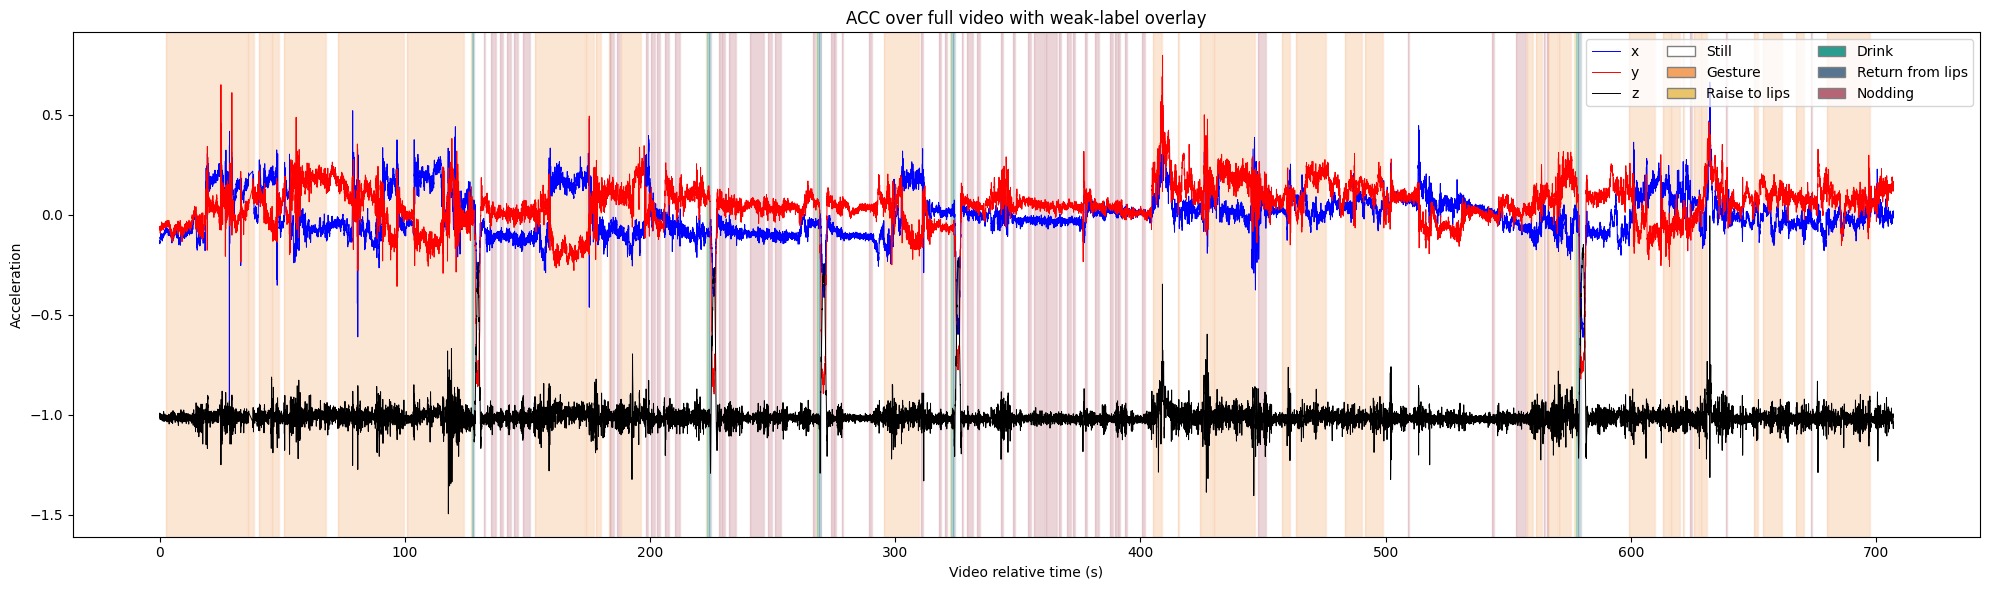

In [21]:
# Plot weak labels on the full video-aligned ACC subset
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

WEAK_LABEL_FILE = PROJECT_ROOT / "weak_label" / f"weak_labels_{PARTICIPANT_ID}_{VIDEO_NAME}.csv"
WEAK_LABEL_OVERLAY_PNG = OUTPUT_DIR / f"weak_labels_overlay_{PARTICIPANT_ID}_{VIDEO_NAME}.png"

label_to_state = {
    "Still": 0,
    "Gesture": 1,
    "Raise to lips": 2,
    "Drink": 3,
    "Return from lips": 4,
    "Nodding": 5,
}
state_to_name = {
    0: "Still",
    1: "Gesture",
    2: "Raise to lips",
    3: "Drink",
    4: "Return from lips",
    5: "Nodding",
}
state_colors = {
    0: "white",
    1: "#f4a261",
    2: "#e9c46a",
    3: "#2a9d8f",
    4: "#577590",
    5: "#b56576",
}

plt.style.use("default")
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"
plt.rcParams["savefig.edgecolor"] = "white"
plt.rcParams["savefig.transparent"] = False

acc_video = pd.read_csv(ACC_VIDEO_CSV)
acc_video["time"] = pd.to_datetime(acc_video["time"])
acc_video["time_rel_s"] = (acc_video["time"] - video_start).dt.total_seconds()

weak_df = pd.read_csv(WEAK_LABEL_FILE)
weak_df["time"] = pd.to_datetime(weak_df["time"])
weak_df = weak_df.sort_values("time").reset_index(drop=True)
weak_df["time_rel_s"] = (weak_df["time"] - video_start).dt.total_seconds()

weak_runs = []
if not weak_df.empty:
    start_idx = 0
    for i in range(1, len(weak_df) + 1):
        if i == len(weak_df) or weak_df.loc[i, "weak_label"] != weak_df.loc[i - 1, "weak_label"]:
            weak_runs.append((
                weak_df.loc[start_idx, "time_rel_s"],
                weak_df.loc[i - 1, "time_rel_s"],
                weak_df.loc[i - 1, "weak_label"],
            ))
            start_idx = i

fig, ax = plt.subplots(1, 1, figsize=(20, 6))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

for start_time, end_time, weak_label in weak_runs:
    weak_state = label_to_state.get(str(weak_label), 0)
    ax.axvspan(start_time, end_time, color=state_colors[int(weak_state)], alpha=0.28)

ax.plot(acc_video["time_rel_s"], acc_video["x"], label="x", color="blue", linewidth=0.7)
ax.plot(acc_video["time_rel_s"], acc_video["y"], label="y", color="red", linewidth=0.7)
ax.plot(acc_video["time_rel_s"], acc_video["z"], label="z", color="black", linewidth=0.7)
ax.set_title("ACC over full video with weak-label overlay")
ax.set_ylabel("Acceleration")
ax.set_xlabel("Video relative time (s)")

legend_handles = [Patch(facecolor=state_colors[s], edgecolor="gray", label=state_to_name[s]) for s in [0, 1, 2, 3, 4, 5]]
line_handles, line_labels = ax.get_legend_handles_labels()
ax.legend(line_handles + legend_handles, line_labels + [state_to_name[s] for s in [0, 1, 2, 3, 4, 5]], loc="upper right", ncol=3)

fig.tight_layout()
fig.savefig(WEAK_LABEL_OVERLAY_PNG, dpi=200, bbox_inches="tight", facecolor="white", edgecolor="white", transparent=False)
print(f"Saved weak-label overlay plot to: {WEAK_LABEL_OVERLAY_PNG}")
WEAK_LABEL_OVERLAY_PNG


In [22]:
import json
import pandas as pd

chatgpt_results = [
{
"window_id": 100,
"predicted_class": "Gesture",
"reason": "Low to moderate multi-axis variation with small reorientation changes and no stable rest plateau. The motion looks like light handling rather than a mouth-directed action."
},
{
"window_id": 101,
"predicted_class": "Still",
"reason": "Very small tilt range, low axis variability, and a stable gravity-dominated posture throughout. This window is closest to a resting cup state."
},
{
"window_id": 102,
"predicted_class": "Gesture",
"reason": "Noticeable variability, especially on one axis, with irregular low-angle motion but no sustained upward trajectory. This is more consistent with handling or gesture than drinking."
},
{
"window_id": 103,
"predicted_class": "Gesture",
"reason": "Moderate movement persists with elevated low-angle posture, but there is no large monotonic raise and no sustained high-angle hold. The pattern fits general cup movement."
},
{
"window_id": 104,
"predicted_class": "Gesture",
"reason": "Small to moderate reorientation with clear motion above rest, yet the tilt stays low and the trajectory is not strongly mouth-directed. This is best read as light gesture."
},
{
"window_id": 105,
"predicted_class": "Gesture",
"reason": "Similar to the adjacent windows, the signal shows modest variability and mild posture changes without a stable still pattern. It looks like continued low-intensity handling."
},
{
"window_id": 106,
"predicted_class": "Gesture",
"reason": "The cup remains mildly active with moderate low-angle motion and no sharp start or stop structure. This is better explained by gesture than by stillness."
},
{
"window_id": 107,
"predicted_class": "Still",
"reason": "The window is relatively stable, with a narrow tilt band and limited axis fluctuation. This is closer to a quiet resting hold than to active manipulation."
},
{
"window_id": 108,
"predicted_class": "Gesture",
"reason": "There is a broader tilt excursion than in the surrounding still windows, but it stays far below drinking angle and does not form a clean raise. This looks like irregular handling."
},
{
"window_id": 109,
"predicted_class": "Gesture",
"reason": "Tilt fluctuates between low and moderate values with irregular multi-axis motion. The pattern is too variable for Still and not structured enough for raise or return."
},
{
"window_id": 110,
"predicted_class": "Gesture",
"reason": "This window continues the moderate low-angle movement seen before the large event, with no sustained high-angle plateau. It is most consistent with gesture or repositioning."
},
{
"window_id": 111,
"predicted_class": "Raise to lips",
"reason": "The window starts at moderate low angle and ends with a strong, smooth climb into very large tilt near the end. That is a clear lift-toward-mouth pattern."
},
{
"window_id": 112,
"predicted_class": "Drink",
"reason": "A long central portion of the window stays at very large tilt well above 40 degrees, forming a sustained high-angle hold. This is the strongest drinking window in the segment."
},
{
"window_id": 113,
"predicted_class": "Return from lips",
"reason": "The window begins at very high tilt and then steadily drops back toward low angles. This is a clear lowering movement after a drinking hold."
},
{
"window_id": 114,
"predicted_class": "Still",
"reason": "After the return, the signal settles into low variability with a narrow low-angle range. The cup appears to be resting again."
},
{
"window_id": 115,
"predicted_class": "Still",
"reason": "Small axis standard deviations and a compact tilt profile indicate a stable posture. There is no meaningful event-like motion here."
},
{
"window_id": 116,
"predicted_class": "Still",
"reason": "The pattern remains quiet and gravity-dominated, with only minor fluctuations. This is consistent with a stationary cup."
},
{
"window_id": 117,
"predicted_class": "Still",
"reason": "Low motion intensity and a narrow angle band persist through the window. The signal is characteristic of rest rather than active movement."
},
{
"window_id": 118,
"predicted_class": "Still",
"reason": "One of the quieter windows in this segment, with very limited tilt and axis variability. This is strong evidence of stillness."
},
{
"window_id": 119,
"predicted_class": "Still",
"reason": "Extremely stable axis relationships and very small fluctuations indicate a resting posture. No gesture-like burst or directed movement is visible."
},
{
"window_id": 120,
"predicted_class": "Still",
"reason": "The cup holds a nearly fixed orientation with minimal movement. This is clearly a still window."
},
{
"window_id": 121,
"predicted_class": "Still",
"reason": "The signal stays compact and low-amplitude with no event structure. This remains within a quiet resting segment."
},
{
"window_id": 122,
"predicted_class": "Still",
"reason": "Slightly more variation than the quietest windows, but the motion is still small and not directional. The best label is Still."
},
{
"window_id": 123,
"predicted_class": "Still",
"reason": "The posture remains stable with low tilt dispersion and limited multi-axis change. This is a resting hold."
},
{
"window_id": 124,
"predicted_class": "Still",
"reason": "Low-intensity signal and narrow tilt range continue without any clear action onset. The cup appears stationary."
},
{
"window_id": 125,
"predicted_class": "Still",
"reason": "The window shows only minor fluctuations around a fixed orientation. This remains a still period."
},
{
"window_id": 126,
"predicted_class": "Still",
"reason": "Very modest axis variation and a stable low-angle posture dominate the window. No meaningful manipulation is evident."
},
{
"window_id": 127,
"predicted_class": "Still",
"reason": "The signal is quiet and compact, with no strong irregular bursts or monotonic raise pattern. This is consistent with stillness."
},
{
"window_id": 128,
"predicted_class": "Still",
"reason": "Another very stable window with low movement intensity and a narrow tilt band. This is clearly Still."
},
{
"window_id": 129,
"predicted_class": "Still",
"reason": "There is a little more angle spread than in the quietest windows, but the overall posture remains stable and low-energy. Still fits best."
},
{
"window_id": 130,
"predicted_class": "Gesture",
"reason": "Movement increases relative to the preceding still stretch, with broader low-angle variation and more visible handling. It does not yet form a clear raise."
},
{
"window_id": 131,
"predicted_class": "Gesture",
"reason": "The window shows moderate low-angle activity and a gradual build in motion, but without a decisive mouth-directed lift. This is better treated as gesture or repositioning."
},
{
"window_id": 132,
"predicted_class": "Gesture",
"reason": "Mild to moderate movement continues, with low to mid tilt but no large-angle transition. This remains handling rather than drinking."
},
{
"window_id": 133,
"predicted_class": "Raise to lips",
"reason": "Most of the window is low-angle, then the tilt rises sharply in the final portion and crosses 40 degrees. This is a clear lift-to-mouth transition."
},
{
"window_id": 134,
"predicted_class": "Drink",
"reason": "This window contains a long sustained high-angle segment well above 40 degrees, reaching deep into drinking posture. That stable elevated hold matches Drink."
},
{
"window_id": 135,
"predicted_class": "Return from lips",
"reason": "The window starts high and then declines steadily back toward low angles. This is a lowering phase immediately after drinking."
},
{
"window_id": 136,
"predicted_class": "Still",
"reason": "After the return, the signal settles again into a quiet low-angle state with limited variability. This is most consistent with rest."
},
{
"window_id": 137,
"predicted_class": "Still",
"reason": "Low axis variability and a narrow tilt band dominate the window. There is no event-like structure or irregular burst."
},
{
"window_id": 138,
"predicted_class": "Still",
"reason": "The cup remains in a stable posture with only small fluctuations. This window belongs to the post-event still segment."
},
{
"window_id": 139,
"predicted_class": "Still",
"reason": "Motion is minimal and the orientation remains steady. This is a quiet resting hold."
},
{
"window_id": 140,
"predicted_class": "Still",
"reason": "Very small axis spread and a compact tilt range indicate strong stability. The cup is effectively at rest."
},
{
"window_id": 141,
"predicted_class": "Still",
"reason": "One of the most stable windows in this group, with very low movement intensity. This clearly fits Still."
},
{
"window_id": 142,
"predicted_class": "Still",
"reason": "The signal remains tightly clustered and low-energy, with no signs of directed transport or gesture bursts. Still is the best match."
},
{
"window_id": 143,
"predicted_class": "Still",
"reason": "The window continues the stable resting pattern with negligible variation. There is no evidence of active manipulation."
},
{
"window_id": 144,
"predicted_class": "Still",
"reason": "Slightly more movement than the quietest windows, but the posture remains stable and low-angle overall. This is still closer to rest than to gesture."
},
{
"window_id": 145,
"predicted_class": "Gesture",
"reason": "Motion becomes more active again, with broader tilt fluctuation and moderate multi-axis variability, but without a clear raise or high-angle hold. This looks like handling."
},
{
"window_id": 146,
"predicted_class": "Gesture",
"reason": "Sustained moderate movement and repeated low-to-mid tilt changes are present, but the action stays well below drinking angle. Gesture fits best."
},
{
"window_id": 147,
"predicted_class": "Gesture",
"reason": "The signal remains active with moderate variability and irregular orientation changes. It is too dynamic for Still and too shallow for Drink."
},
{
"window_id": 148,
"predicted_class": "Gesture",
"reason": "This is a more vigorous handling window with larger axis variability and stronger low-to-mid angle motion, but no sustained mouth-level posture. It is best labeled Gesture."
},
{
"window_id": 149,
"predicted_class": "Gesture",
"reason": "The final window continues the active handling pattern, with broad moderate tilt changes and no stable high-angle plateau. This is not Drink and is most consistent with Gesture."
}
]

window_ids = [item["window_id"] for item in chatgpt_results]
result_name = f"{batch_name}_predictions_local_chatgpt.json"
result_path_chatgpt = batch_dir / result_name
result_path_chatgpt.write_text(json.dumps(chatgpt_results, indent=2, ensure_ascii=False), encoding="utf-8")

print(f"Saved ChatGPT results to: {result_path_chatgpt}")
# pd.DataFrame(chatgpt_results)


Saved ChatGPT results to: G:\TUD_CESE\OneDrive - Delft University of Technology\Smart Cup\relativeWorks\hargpt_dir\cup_integration\outputs\hargpt_windows_100_to_149_65_GL040226\hargpt_windows_100_to_149_65_GL040226_predictions_local_chatgpt.json


In [23]:
gemini_results = [
  {
    "window_id": 50,
    "predicted_class": "Raise to lips",
    "reason": "Tilt angle increases from near 0 to 22 degrees, indicating the start of a lifting motion."
  },
  {
    "window_id": 51,
    "predicted_class": "Gesture",
    "reason": "Tilt angle fluctuates up to 22 degrees with moderate acceleration variability, consistent with hand movements."
  },
  {
    "window_id": 52,
    "predicted_class": "Gesture",
    "reason": "Moderate tilt around 11-19 degrees with stable acceleration, suggesting holding and gesturing."
  },
  {
    "window_id": 53,
    "predicted_class": "Gesture",
    "reason": "Stable tilt around 12-19 degrees, consistent with holding and small gestures."
  },
  {
    "window_id": 54,
    "predicted_class": "Gesture",
    "reason": "Stable tilt angle around 11-19 degrees with moderate movement."
  },
  {
    "window_id": 55,
    "predicted_class": "Gesture",
    "reason": "Maintains a steady tilt around 12-19 degrees, characteristic of gesturing while holding."
  },
  {
    "window_id": 56,
    "predicted_class": "Return from lips",
    "reason": "Tilt angle drops from 18 to near 0, indicating the cup is being placed back down."
  },
  {
    "window_id": 57,
    "predicted_class": "Gesture",
    "reason": "Quick fluctuation in tilt angle up to 21 degrees, suggesting a brief hand gesture."
  },
  {
    "window_id": 58,
    "predicted_class": "Gesture",
    "reason": "Small tilt fluctuations between 2 and 15 degrees with low standard deviation."
  },
  {
    "window_id": 59,
    "predicted_class": "Gesture",
    "reason": "Tilt angle spikes to 18 degrees and drops, indicating a short gesture."
  },
  {
    "window_id": 60,
    "predicted_class": "Raise to lips",
    "reason": "Rapid increase in tilt angle up to 73 degrees, strongly indicative of lifting to drink."
  },
  {
    "window_id": 61,
    "predicted_class": "Drink",
    "reason": "Sustained high tilt angles exceeding 40 degrees (up to 71 degrees), consistent with drinking."
  },
  {
    "window_id": 62,
    "predicted_class": "Drink",
    "reason": "Tilt angle reaches high values over 70 degrees, confirming a drinking action."
  },
  {
    "window_id": 63,
    "predicted_class": "Return from lips",
    "reason": "Tilt angle decreases from 16 down to 3 degrees, indicating the cup is being lowered."
  },
  {
    "window_id": 64,
    "predicted_class": "Still",
    "reason": "Low motion intensity and stable tilt around 3-12 degrees, consistent with being stationary."
  },
  {
    "window_id": 65,
    "predicted_class": "Still",
    "reason": "Minimal acceleration variability and stable tilt, indicating the cup is still."
  },
  {
    "window_id": 66,
    "predicted_class": "Still",
    "reason": "Very low standard deviation in all axes and flat tilt angle."
  },
  {
    "window_id": 67,
    "predicted_class": "Still",
    "reason": "Stable gravity orientation with minimal tilt variation."
  },
  {
    "window_id": 68,
    "predicted_class": "Still",
    "reason": "Low motion intensity and steady tilt angle."
  },
  {
    "window_id": 69,
    "predicted_class": "Still",
    "reason": "Consistently low tilt and minimal axis variation."
  },
  {
    "window_id": 70,
    "predicted_class": "Still",
    "reason": "Very stable orientation and lack of bursty movement."
  },
  {
    "window_id": 71,
    "predicted_class": "Gesture",
    "reason": "Tilt angle increases up to 30 degrees, indicating moderate hand movement."
  },
  {
    "window_id": 72,
    "predicted_class": "Gesture",
    "reason": "Tilt angle fluctuates between 12 and 21 degrees, showing active holding."
  },
  {
    "window_id": 73,
    "predicted_class": "Gesture",
    "reason": "Tilt angle remains elevated around 11-21 degrees, consistent with gestures."
  },
  {
    "window_id": 74,
    "predicted_class": "Still",
    "reason": "Low motion intensity and tilt settling back to lower values."
  },
  {
    "window_id": 75,
    "predicted_class": "Still",
    "reason": "Stable axes and low tilt variation, characteristic of resting."
  },
  {
    "window_id": 76,
    "predicted_class": "Still",
    "reason": "Minimal acceleration variability, indicating a stationary state."
  },
  {
    "window_id": 77,
    "predicted_class": "Still",
    "reason": "Low standard deviation and steady tilt."
  },
  {
    "window_id": 78,
    "predicted_class": "Still",
    "reason": "No significant movement; stable gravity orientation."
  },
  {
    "window_id": 79,
    "predicted_class": "Still",
    "reason": "Consistently low motion intensity."
  },
  {
    "window_id": 80,
    "predicted_class": "Still",
    "reason": "Stable tilt and minimal axis fluctuations."
  },
  {
    "window_id": 81,
    "predicted_class": "Still",
    "reason": "Flat tilt angle and very low acceleration standard deviation."
  },
  {
    "window_id": 82,
    "predicted_class": "Still",
    "reason": "No notable motion; cup appears resting."
  },
  {
    "window_id": 83,
    "predicted_class": "Still",
    "reason": "Very low motion intensity and stable orientation."
  },
  {
    "window_id": 84,
    "predicted_class": "Still",
    "reason": "Steady tilt and low variance across all axes."
  },
  {
    "window_id": 85,
    "predicted_class": "Still",
    "reason": "Minimal movement detected; steady state."
  },
  {
    "window_id": 86,
    "predicted_class": "Still",
    "reason": "Low motion intensity with flat tilt."
  },
  {
    "window_id": 87,
    "predicted_class": "Still",
    "reason": "Stable gravity orientation with minimal tilt variation."
  },
  {
    "window_id": 88,
    "predicted_class": "Still",
    "reason": "Very stable orientation and lack of bursty movement."
  },
  {
    "window_id": 89,
    "predicted_class": "Still",
    "reason": "Consistently low tilt and minimal axis variation."
  },
  {
    "window_id": 90,
    "predicted_class": "Still",
    "reason": "Low standard deviation and steady tilt."
  },
  {
    "window_id": 91,
    "predicted_class": "Still",
    "reason": "No significant movement; stable gravity orientation."
  },
  {
    "window_id": 92,
    "predicted_class": "Still",
    "reason": "Minimal acceleration variability, indicating a stationary state."
  },
  {
    "window_id": 93,
    "predicted_class": "Still",
    "reason": "Low motion intensity and steady tilt angle."
  },
  {
    "window_id": 94,
    "predicted_class": "Still",
    "reason": "Flat tilt angle and very low acceleration standard deviation."
  },
  {
    "window_id": 95,
    "predicted_class": "Still",
    "reason": "Stable tilt and minimal axis fluctuations."
  },
  {
    "window_id": 96,
    "predicted_class": "Still",
    "reason": "No notable motion; cup appears resting."
  },
  {
    "window_id": 97,
    "predicted_class": "Still",
    "reason": "Very low motion intensity and stable orientation."
  },
  {
    "window_id": 98,
    "predicted_class": "Still",
    "reason": "Steady tilt and low variance across all axes."
  },
  {
    "window_id": 99,
    "predicted_class": "Still",
    "reason": "Minimal movement detected; steady state."
  }
]

window_ids = [item["window_id"] for item in gemini_results]
result_name = f"{batch_name}_predictions_local_gemini.json"
result_path_gemini = batch_dir / result_name
result_path_gemini.write_text(json.dumps(gemini_results, indent=2, ensure_ascii=False), encoding="utf-8")

print(f"Saved gemini results to: {result_path_gemini}")
# pd.DataFrame(chatgpt_results)


Saved gemini results to: G:\TUD_CESE\OneDrive - Delft University of Technology\Smart Cup\relativeWorks\hargpt_dir\cup_integration\outputs\hargpt_windows_100_to_149_65_GL040226\hargpt_windows_100_to_149_65_GL040226_predictions_local_gemini.json


Saved comparison plot to: G:\TUD_CESE\OneDrive - Delft University of Technology\Smart Cup\relativeWorks\hargpt_dir\cup_integration\outputs\hargpt_windows_100_to_149_65_GL040226\hargpt_windows_100_to_149_65_GL040226_predictions_chatgpt_vs_weak_labels.png


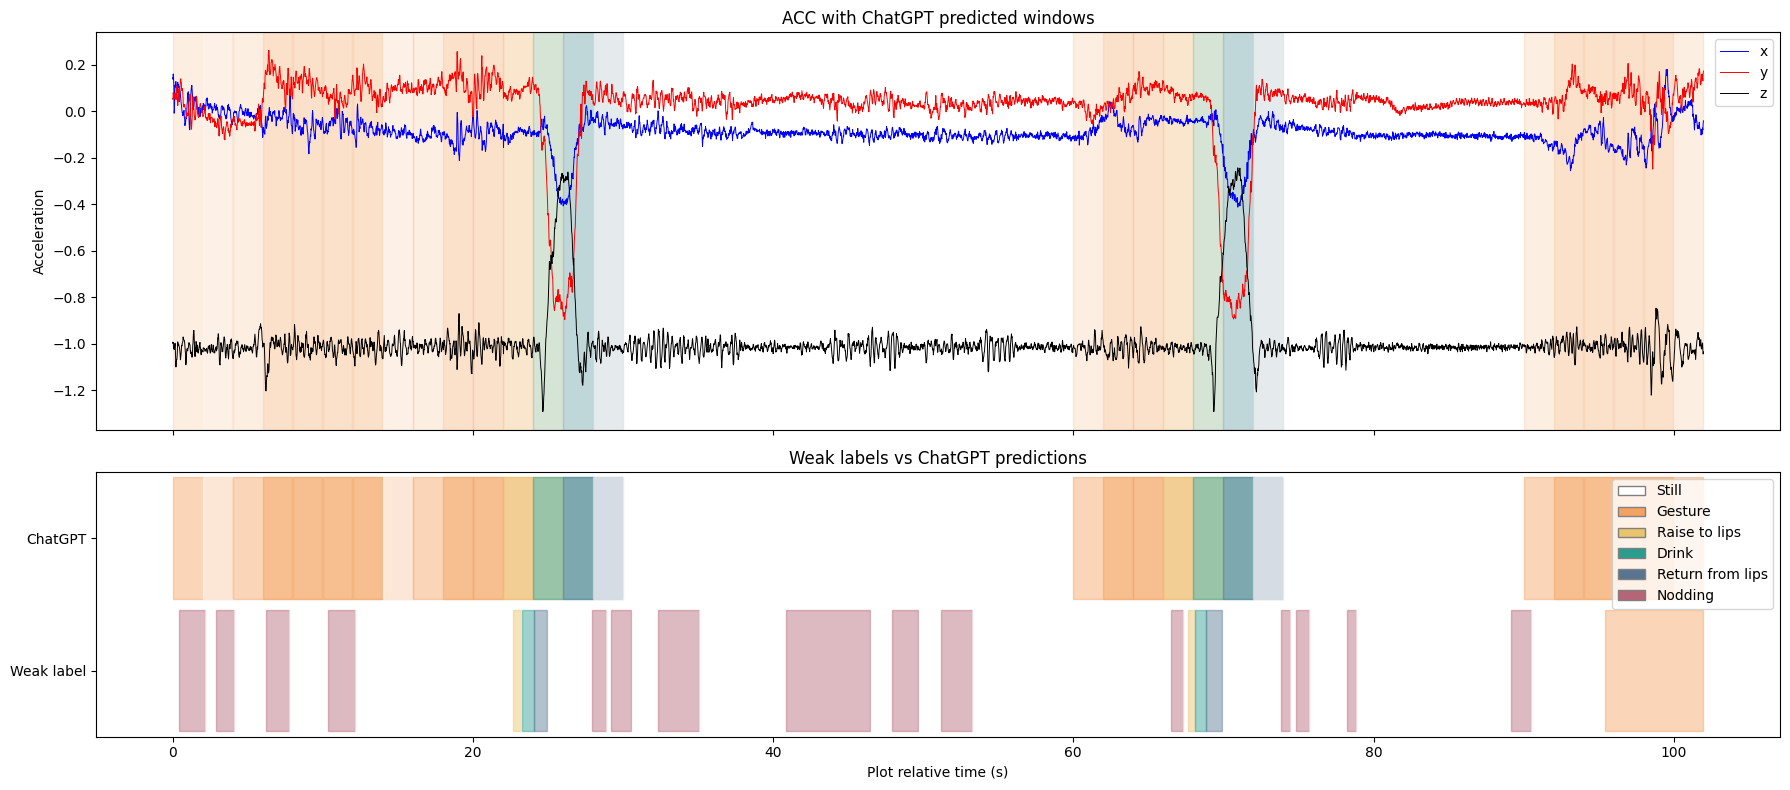

In [24]:
WINDOW_RANGE = f"{min(window_ids)}_{max(window_ids)}"
RESULT_PATH_CHATGPT = result_path_chatgpt
WEAK_LABEL_FILE = PROJECT_ROOT / "weak_label" / f"weak_labels_{PARTICIPANT_ID}_{VIDEO_NAME}.csv"
COMPARE_PNG = batch_dir / f"{batch_name}_predictions_chatgpt_vs_weak_labels.png"

label_to_state = {
    "Still": 0,
    "Gesture": 1,
    "Raise to lips": 2,
    "Drink": 3,
    "Return from lips": 4,
    "Nodding": 5,
}
state_to_name = {
    0: "Still",
    1: "Gesture",
    2: "Raise to lips",
    3: "Drink",
    4: "Return from lips",
    5: "Nodding",
}
state_colors = {
    0: "white",
    1: "#f4a261",
    2: "#e9c46a",
    3: "#2a9d8f",
    4: "#577590",
    5: "#b56576",
}

fine_class_to_state = {
    "still": 0,
    "hand switch": 1,
    "gesture": 1,
    "nodding": 5,
    "raise to lips": 2,
    "drink": 3,
    "return from lips": 4,
    "uncertain": 1,
}


def normalize_label(value):
    if pd.isna(value):
        return pd.NA
    return str(value).strip().lower()


def map_prediction_to_state(value):
    normalized = normalize_label(value)
    if pd.isna(normalized):
        return pd.NA
    if normalized == "still":
        return 0
    if normalized in fine_class_to_state:
        return fine_class_to_state[normalized]
    title_label = str(value).strip().title()
    if title_label in label_to_state:
        return label_to_state[title_label]
    return pd.NA


window_index_df = pd.read_csv(WINDOW_INDEX_CSV)
window_index_df["start_time"] = pd.to_datetime(window_index_df["start_time"])
window_index_df["end_time"] = pd.to_datetime(window_index_df["end_time"])
acc_video = pd.read_csv(ACC_VIDEO_CSV)
acc_video["time"] = pd.to_datetime(acc_video["time"])
weak_df = pd.read_csv(WEAK_LABEL_FILE)
weak_df["time"] = pd.to_datetime(weak_df["time"])
predictions = json.loads(RESULT_PATH_CHATGPT.read_text(encoding="utf-8"))
pred_df = pd.DataFrame(predictions)

required_cols = {"window_id", "predicted_class"}
missing_cols = required_cols - set(pred_df.columns)
if missing_cols:
    raise ValueError(f"Prediction JSON missing required fields: {sorted(missing_cols)}")

pred_df["predicted_state"] = pred_df["predicted_class"].map(map_prediction_to_state)
pred_df = pred_df.merge(window_index_df[["window_id", "start_time", "end_time"]], on="window_id", how="left")
pred_df = pred_df.sort_values("window_id").reset_index(drop=True)

invalid_rows = pred_df[
    pred_df[["predicted_state", "start_time", "end_time"]].isna().any(axis=1)
].copy()
if not invalid_rows.empty:
    print("Invalid prediction rows detected:")
    display(invalid_rows[["window_id", "predicted_class", "predicted_state", "start_time", "end_time"]])
    pred_df = pred_df.drop(index=invalid_rows.index).reset_index(drop=True)

if pred_df.empty:
    raise ValueError("No valid prediction windows available for plotting after validation.")

pred_df["predicted_state"] = pred_df["predicted_state"].astype(int)

plot_start = pred_df["start_time"].min()
plot_end = pred_df["end_time"].max()
plot_origin = plot_start
acc_plot = acc_video[(acc_video["time"] >= plot_start) & (acc_video["time"] <= plot_end)].copy().reset_index(drop=True)
weak_plot = weak_df[(weak_df["time"] >= plot_start) & (weak_df["time"] <= plot_end)].copy().reset_index(drop=True)
acc_plot["time_rel_s"] = (acc_plot["time"] - plot_origin).dt.total_seconds()
if not weak_plot.empty:
    weak_plot["time_rel_s"] = (weak_plot["time"] - plot_origin).dt.total_seconds()
pred_df["start_rel_s"] = (pred_df["start_time"] - plot_origin).dt.total_seconds()
pred_df["end_rel_s"] = (pred_df["end_time"] - plot_origin).dt.total_seconds()

fig, axes = plt.subplots(2, 1, figsize=(18, 8), sharex=True, gridspec_kw={"height_ratios": [3, 2]})
ax0, ax1 = axes
fig.patch.set_facecolor("white")
ax0.set_facecolor("white")
ax1.set_facecolor("white")
for ax in (ax0, ax1):
    ax.tick_params(axis="both", colors="black", labelcolor="black")
    ax.xaxis.label.set_color("black")
    ax.yaxis.label.set_color("black")
    ax.title.set_color("black")
    for spine in ax.spines.values():
        spine.set_color("black")


ax0.plot(acc_plot["time_rel_s"], acc_plot["x"], label="x", color="blue", linewidth=0.7)
ax0.plot(acc_plot["time_rel_s"], acc_plot["y"], label="y", color="red", linewidth=0.7)
ax0.plot(acc_plot["time_rel_s"], acc_plot["z"], label="z", color="black", linewidth=0.7)
for row in pred_df.itertuples(index=False):
    ax0.axvspan(row.start_rel_s, row.end_rel_s, color=state_colors[row.predicted_state], alpha=0.18)
ax0.set_title("ACC with ChatGPT predicted windows")
ax0.set_ylabel("Acceleration")
ax0.legend(loc="upper right")

for row in pred_df.itertuples(index=False):
    ax1.axvspan(row.start_rel_s, row.end_rel_s, ymin=0.52, ymax=0.98, color=state_colors[row.predicted_state], alpha=0.45)
    # ax1.text(row.start_rel_s + (row.end_rel_s - row.start_rel_s) / 2, 0.75, f"P{row.window_id}:{row.predicted_class}", ha="center", va="center", fontsize=8)

weak_runs = []
if not weak_plot.empty:
    weak_plot = weak_plot.sort_values("time").reset_index(drop=True)
    start_idx = 0
    for i in range(1, len(weak_plot) + 1):
        if i == len(weak_plot) or weak_plot.loc[i, "weak_label"] != weak_plot.loc[i - 1, "weak_label"]:
            weak_runs.append((weak_plot.loc[start_idx, "time_rel_s"], weak_plot.loc[i - 1, "time_rel_s"], weak_plot.loc[i - 1, "weak_label"]))
            start_idx = i

for start_time, end_time, weak_label in weak_runs:
    weak_state = label_to_state.get(str(weak_label), 0)
    ax1.axvspan(start_time, end_time, ymin=0.02, ymax=0.48, color=state_colors[int(weak_state)], alpha=0.45)
    # ax1.text(start_time + (end_time - start_time) / 2, 0.25, f"W:{weak_label}", ha="center", va="center", fontsize=8)

ax1.set_ylim(0, 1)
ax1.set_yticks([0.25, 0.75])
ax1.set_yticklabels(["Weak label", "ChatGPT"])
ax1.set_title("Weak labels vs ChatGPT predictions")
ax1.set_xlabel("Plot relative time (s)")

legend_handles = [Patch(facecolor=state_colors[s], edgecolor="gray", label=state_to_name[s]) for s in [0, 1, 2, 3, 4, 5]]
ax1.legend(handles=legend_handles, loc="upper right")
fig.tight_layout()
fig.savefig(COMPARE_PNG, dpi=200, bbox_inches="tight", facecolor="white", edgecolor="white", transparent=False)
print(f"Saved comparison plot to: {COMPARE_PNG}")
# pred_df[["window_id", "predicted_class", "predicted_state", "start_time", "end_time"]]

Saved comparison plot to: G:\TUD_CESE\OneDrive - Delft University of Technology\Smart Cup\relativeWorks\hargpt_dir\cup_integration\outputs\hargpt_windows_100_to_149_65_GL040226\hargpt_windows_100_to_149_65_GL040226_predictions_gemini_vs_weak_labels.png


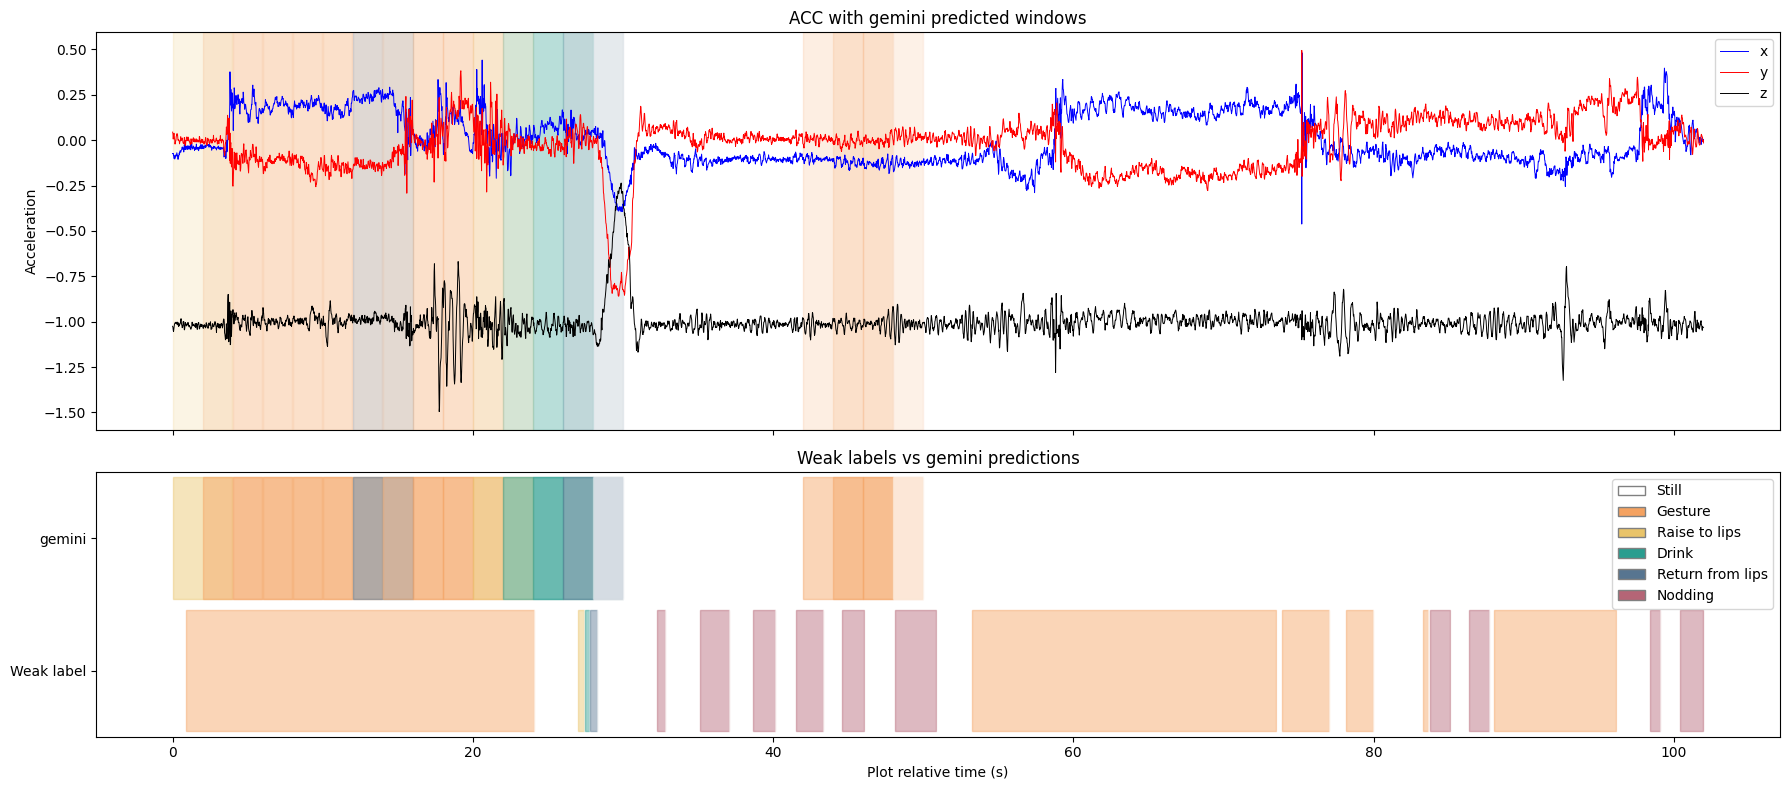

In [25]:
WINDOW_RANGE = f"{min(window_ids)}_{max(window_ids)}"
RESULT_PATH_GEMINI = result_path_gemini
WEAK_LABEL_FILE = PROJECT_ROOT / "weak_label" / f"weak_labels_{PARTICIPANT_ID}_{VIDEO_NAME}.csv"
COMPARE_PNG = batch_dir / f"{batch_name}_predictions_gemini_vs_weak_labels.png"

label_to_state = {
    "Still": 0,
    "Gesture": 1,
    "Raise to lips": 2,
    "Drink": 3,
    "Return from lips": 4,
    "Nodding": 5,
}
state_to_name = {
    0: "Still",
    1: "Gesture",
    2: "Raise to lips",
    3: "Drink",
    4: "Return from lips",
    5: "Nodding",
}
state_colors = {
    0: "white",
    1: "#f4a261",
    2: "#e9c46a",
    3: "#2a9d8f",
    4: "#577590",
    5: "#b56576",
}

fine_class_to_state = {
    "still": 0,
    "hand switch": 1,
    "gesture": 1,
    "nodding": 5,
    "raise to lips": 2,
    "drink": 3,
    "return from lips": 4,
    "uncertain": 1,
}


def normalize_label(value):
    if pd.isna(value):
        return pd.NA
    return str(value).strip().lower()


def map_prediction_to_state(value):
    normalized = normalize_label(value)
    if pd.isna(normalized):
        return pd.NA
    if normalized == "still":
        return 0
    if normalized in fine_class_to_state:
        return fine_class_to_state[normalized]
    title_label = str(value).strip().title()
    if title_label in label_to_state:
        return label_to_state[title_label]
    return pd.NA


window_index_df = pd.read_csv(WINDOW_INDEX_CSV)
window_index_df["start_time"] = pd.to_datetime(window_index_df["start_time"])
window_index_df["end_time"] = pd.to_datetime(window_index_df["end_time"])
acc_video = pd.read_csv(ACC_VIDEO_CSV)
acc_video["time"] = pd.to_datetime(acc_video["time"])
weak_df = pd.read_csv(WEAK_LABEL_FILE)
weak_df["time"] = pd.to_datetime(weak_df["time"])
predictions = json.loads(RESULT_PATH.read_text(encoding="utf-8"))
pred_df = pd.DataFrame(predictions)

required_cols = {"window_id", "predicted_class"}
missing_cols = required_cols - set(pred_df.columns)
if missing_cols:
    raise ValueError(f"Prediction JSON missing required fields: {sorted(missing_cols)}")

pred_df["predicted_state"] = pred_df["predicted_class"].map(map_prediction_to_state)
pred_df = pred_df.merge(window_index_df[["window_id", "start_time", "end_time"]], on="window_id", how="left")
pred_df = pred_df.sort_values("window_id").reset_index(drop=True)

invalid_rows = pred_df[
    pred_df[["predicted_state", "start_time", "end_time"]].isna().any(axis=1)
].copy()
if not invalid_rows.empty:
    print("Invalid prediction rows detected:")
    display(invalid_rows[["window_id", "predicted_class", "predicted_state", "start_time", "end_time"]])
    pred_df = pred_df.drop(index=invalid_rows.index).reset_index(drop=True)

if pred_df.empty:
    raise ValueError("No valid prediction windows available for plotting after validation.")

pred_df["predicted_state"] = pred_df["predicted_state"].astype(int)

plot_start = pred_df["start_time"].min()
plot_end = pred_df["end_time"].max()
plot_origin = plot_start
acc_plot = acc_video[(acc_video["time"] >= plot_start) & (acc_video["time"] <= plot_end)].copy().reset_index(drop=True)
weak_plot = weak_df[(weak_df["time"] >= plot_start) & (weak_df["time"] <= plot_end)].copy().reset_index(drop=True)
acc_plot["time_rel_s"] = (acc_plot["time"] - plot_origin).dt.total_seconds()
if not weak_plot.empty:
    weak_plot["time_rel_s"] = (weak_plot["time"] - plot_origin).dt.total_seconds()
pred_df["start_rel_s"] = (pred_df["start_time"] - plot_origin).dt.total_seconds()
pred_df["end_rel_s"] = (pred_df["end_time"] - plot_origin).dt.total_seconds()

fig, axes = plt.subplots(2, 1, figsize=(18, 8), sharex=True, gridspec_kw={"height_ratios": [3, 2]})
ax0, ax1 = axes
fig.patch.set_facecolor("white")
ax0.set_facecolor("white")
ax1.set_facecolor("white")
for ax in (ax0, ax1):
    ax.tick_params(axis="both", colors="black", labelcolor="black")
    ax.xaxis.label.set_color("black")
    ax.yaxis.label.set_color("black")
    ax.title.set_color("black")
    for spine in ax.spines.values():
        spine.set_color("black")


ax0.plot(acc_plot["time_rel_s"], acc_plot["x"], label="x", color="blue", linewidth=0.7)
ax0.plot(acc_plot["time_rel_s"], acc_plot["y"], label="y", color="red", linewidth=0.7)
ax0.plot(acc_plot["time_rel_s"], acc_plot["z"], label="z", color="black", linewidth=0.7)
for row in pred_df.itertuples(index=False):
    ax0.axvspan(row.start_rel_s, row.end_rel_s, color=state_colors[row.predicted_state], alpha=0.18)
ax0.set_title("ACC with gemini predicted windows")
ax0.set_ylabel("Acceleration")
ax0.legend(loc="upper right")

for row in pred_df.itertuples(index=False):
    ax1.axvspan(row.start_rel_s, row.end_rel_s, ymin=0.52, ymax=0.98, color=state_colors[row.predicted_state], alpha=0.45)
    # ax1.text(row.start_rel_s + (row.end_rel_s - row.start_rel_s) / 2, 0.75, f"P{row.window_id}:{row.predicted_class}", ha="center", va="center", fontsize=8)

weak_runs = []
if not weak_plot.empty:
    weak_plot = weak_plot.sort_values("time").reset_index(drop=True)
    start_idx = 0
    for i in range(1, len(weak_plot) + 1):
        if i == len(weak_plot) or weak_plot.loc[i, "weak_label"] != weak_plot.loc[i - 1, "weak_label"]:
            weak_runs.append((weak_plot.loc[start_idx, "time_rel_s"], weak_plot.loc[i - 1, "time_rel_s"], weak_plot.loc[i - 1, "weak_label"]))
            start_idx = i

for start_time, end_time, weak_label in weak_runs:
    weak_state = label_to_state.get(str(weak_label), 0)
    ax1.axvspan(start_time, end_time, ymin=0.02, ymax=0.48, color=state_colors[int(weak_state)], alpha=0.45)
    # ax1.text(start_time + (end_time - start_time) / 2, 0.25, f"W:{weak_label}", ha="center", va="center", fontsize=8)

ax1.set_ylim(0, 1)
ax1.set_yticks([0.25, 0.75])
ax1.set_yticklabels(["Weak label", "gemini"])
ax1.set_title("Weak labels vs gemini predictions")
ax1.set_xlabel("Plot relative time (s)")

legend_handles = [Patch(facecolor=state_colors[s], edgecolor="gray", label=state_to_name[s]) for s in [0, 1, 2, 3, 4, 5]]
ax1.legend(handles=legend_handles, loc="upper right")
fig.tight_layout()
fig.savefig(COMPARE_PNG, dpi=200, bbox_inches="tight", facecolor="white", edgecolor="white", transparent=False)
print(f"Saved comparison plot to: {COMPARE_PNG}")
# pred_df[["window_id", "predicted_class", "predicted_state", "start_time", "end_time"]]